# Notebook 01: Data Exploration and Data Quality Review

**Project:** MAP Dryer AI  
**Purpose:** establish a trustworthy view of the current MAP dryer prototype dataset before feature engineering or model development.

This notebook verifies the canonical 92-day source against its manifest hash, checks the schema, removes exact duplicate rows from the exploration sample, and reviews numeric distributions.

## Inputs and outputs

- **Input:** `data/processed/MAP_Dryer_Canonical_5s.csv` and its manifest
- **Audit output:** `artifacts/notebook01_canonical_audit.json`
- **Figure output:** `figures/01_Data_Exploration/01_numeric_feature_distributions.png`
- **Prototype feature dictionary:** `config/data_dictionary.yaml`

## Reading guide

Run the cells in order. The notebook is descriptive: it documents data quality and distributions but does not train a model. Notebook 02 consumes the same canonical dataset hash recorded here.


## 1. Environment and display settings

Import the packages used for data preparation and visualisation, then set consistent display defaults for the exploratory work.


In [1]:
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SRC_DIR = next(
    candidate / "src"
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "data" / "raw").is_dir()
)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data.data_cleaning import prepare_dryer_map
from data.feature_catalog import (
    load_feature_catalog,
    select_feature_catalog,
)
from data.project_paths import find_project_root
from stats.descriptive_statistics import descriptive_summary

PROJECT_ROOT = find_project_root()
FIGURE_OUTPUT_DIR = PROJECT_ROOT / "figures" / "01_Data_Exploration"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATA_DICTIONARY_PATH = PROJECT_ROOT / "config" / "data_dictionary.yaml"
feature_catalog = load_feature_catalog(DATA_DICTIONARY_PATH)

sns.set_theme(style="whitegrid")
# Arial has no U+2082 SUBSCRIPT TWO; passing the stack through
# font.family enables matplotlib per-glyph fallback so "H₂O" renders.
plt.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
pd.set_option("display.max_columns", None)
print(f"Python: {platform.python_version()}")


Python: 3.14.6


## Prototype feature dictionary


In [2]:
RAW_NOTEBOOK_FIELDS = [
    "date", "time", "timestamp", "dryer_air_temperature",
    "cooler_air_temperature", "air_flow_rate", "wet_product_feed_rate",
    "product_inlet_temperature", "residence_time", "vacuum",
    "steam_pressure", "fan_speed", "product_density",
    "final_product_temp", "final_moisture_h₂o",
]
display(select_feature_catalog(feature_catalog, RAW_NOTEBOOK_FIELDS))
print("Data dictionary version:", feature_catalog.attrs["version"])


,display_name,unit,unit_status,role,interpretation
feature,,,,,
date,Date,calendar date,defined,identifier,Calendar component of the observation timestamp.
time,Time,clock time,defined,identifier,Clock component of the observation timestamp.
timestamp,Timestamp,datetime,defined,identifier,Date and time combined for chronological order...
dryer_air_temperature,Dryer air temperature,°C,prototype_unit,process_input,Dryer inlet-air temperature.
cooler_air_temperature,Cooler air temperature,°C,prototype_unit,process_input,Cooling-air temperature.
air_flow_rate,Air flow rate,m³/h,defined,process_input,Volumetric airflow rate in cubic metres per hour.
wet_product_feed_rate,Wet product feed rate,m³/h,defined,process_input,Volumetric wet-product feed rate in cubic metr...
product_inlet_temperature,Product inlet temperature,°C,prototype_unit,process_input,Product temperature at dryer entry.
residence_time,Residence time,min,prototype_unit,process_input,Time spent in the drying process.


Data dictionary version: map_dryer_data_dictionary_v1.2


### Interpretation guardrails

- Only exact duplicate rows are removed. A zero, extreme value, or unusual row is not automatically invalid.
- Moisture uses percentage points: `0.075` means `0.075% H₂O`.
- Every feature uses the engineering unit shown in the dictionary above.


## 2. Locate the project and load the canonical source

Notebook 01 now audits the complete 92-day canonical CSV. A bounded deterministic
sample from that same file is retained for readable exploratory plots; it is not
a second dataset.


In [3]:
from canonical_pipeline import CANONICAL_CSV, audit_canonical_dataset
from multirate.preprocessing import RAW_SOURCE_COLUMNS

DATA_PATH = CANONICAL_CSV
canonical_audit = audit_canonical_dataset()

sampled_chunks = []
for chunk in pd.read_csv(DATA_PATH, usecols=RAW_SOURCE_COLUMNS, chunksize=200_000):
    sampled_chunks.append(chunk.iloc[::120])
    sampled_chunks.append(chunk.loc[chunk["Final Moisture (%H2O)"].notna()])
raw_sample = (
    pd.concat(sampled_chunks, ignore_index=True)
    .drop_duplicates(subset=["Date", "Time"])
    .reset_index(drop=True)
)
dryerMAP = prepare_dryer_map(raw_sample)
dryerMAP = dryerMAP.rename(columns={"final_moisture_h2o": "final_moisture_h₂o"})

print(f"Canonical source: {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Full audited rows: {canonical_audit['process_rows']:,}")
print(f"Laboratory samples: {canonical_audit['laboratory_samples']:,}")
print(f"Exploration sample: {len(dryerMAP):,} rows")
dryerMAP.head(10)


C:\Users\pc\Documents\GitHub\PROJECTS\MAP-Dryer-AI\src\data\data_cleaning.py:66: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="raise")


C:\Users\pc\Documents\GitHub\PROJECTS\MAP-Dryer-AI\src\data\data_cleaning.py:75: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(


Canonical source: data\processed\MAP_Dryer_Canonical_5s.csv
Full audited rows: 1,589,760
Laboratory samples: 1,104
Exploration sample: 13,938 rows


,date,time,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,final_moisture_h₂o,timestamp
0,2026-04-16,00:00:00,176.280914,28.465534,24093.359375,26.551008,62.878098,24.45842,48.285721,8.343276,1336.187866,0.957827,48.819279,0.076354,2026-04-16 00:00:00
1,2026-04-16,00:10:00,176.247253,28.464808,24041.408203,26.526165,62.834431,24.458092,48.23806,8.327744,1334.447754,<NA>,<NA>,<NA>,2026-04-16 00:10:00
2,2026-04-16,00:20:00,176.204041,28.529202,24013.298828,26.527637,62.801758,24.453753,48.137894,8.334549,1335.415527,<NA>,<NA>,<NA>,2026-04-16 00:20:00
3,2026-04-16,00:30:00,176.060898,28.574871,24000.318359,26.5562,62.841751,24.446304,48.072853,8.337369,1333.61731,<NA>,<NA>,<NA>,2026-04-16 00:30:00
4,2026-04-16,00:40:00,176.183487,28.596701,23992.591797,26.546183,62.834438,24.443222,48.099754,8.357647,1330.127075,<NA>,<NA>,<NA>,2026-04-16 00:40:00
5,2026-04-16,00:50:00,176.262817,28.576614,24076.205078,26.538513,62.902351,24.495035,48.318642,8.345987,1335.130737,<NA>,<NA>,<NA>,2026-04-16 00:50:00
6,2026-04-16,01:00:00,176.221069,28.582272,24140.015625,26.566822,62.895725,24.495949,48.334667,8.327754,1335.661621,<NA>,<NA>,<NA>,2026-04-16 01:00:00
7,2026-04-16,01:10:00,176.374374,28.568411,24099.390625,26.552504,62.891155,24.475698,48.279808,8.333453,1335.481323,<NA>,<NA>,<NA>,2026-04-16 01:10:00
8,2026-04-16,01:20:00,176.430542,28.632954,24063.613281,26.5767,62.900208,24.45311,48.214199,8.35391,1333.605591,<NA>,<NA>,<NA>,2026-04-16 01:20:00
9,2026-04-16,01:30:00,176.455673,28.748632,24098.623047,26.576944,62.935894,24.448759,48.29723,8.372874,1333.248413,<NA>,<NA>,<NA>,2026-04-16 01:30:00


## 3. Validate the schema and remove exact duplicates

The analysis expects 14 ordered process and quality columns. This step verifies that schema, counts missing values and duplicate rows, removes only exact duplicates, and saves the deduplicated dataset for the next notebook.


In [4]:
expected_columns = [
    'date', 'time', 'dryer_air_temperature', 'cooler_air_temperature',
    'air_flow_rate', 'wet_product_feed_rate', 'product_inlet_temperature',
    'residence_time', 'vacuum', 'steam_pressure', 'fan_speed',
    'product_density', 'final_product_temp', 'final_moisture_h₂o'
]
assert dryerMAP.columns[:len(expected_columns)].tolist() == expected_columns

duplicate_count = int(dryerMAP.duplicated().sum())
dryerMAP_unique = dryerMAP.drop_duplicates().reset_index(drop=True)
validation_summary = pd.Series({
    "full_process_rows": canonical_audit["process_rows"],
    "full_laboratory_samples": canonical_audit["laboratory_samples"],
    "duration_days": canonical_audit["duration_days"],
    "process_interval_seconds": canonical_audit["process_interval_seconds"],
    "laboratory_interval_minutes": canonical_audit["laboratory_interval_minutes"],
    "exploration_sample_rows": len(dryerMAP_unique),
    "sample_duplicate_rows": duplicate_count,
    "all_canonical_checks_pass": all(canonical_audit["checks"].values()),
})
validation_summary


full_process_rows              1589760
full_laboratory_samples           1104
duration_days                     92.0
process_interval_seconds             5
laboratory_interval_minutes        120
exploration_sample_rows          13938
sample_duplicate_rows                0
all_canonical_checks_pass         True
dtype: object

## 4. Prepare the moisture target

`final_moisture_h₂o` is converted to a numeric field. Invalid entries become missing values so later statistics and modelling steps do not treat text values as measurements.


In [5]:
dryerMAP_unique["final_moisture_h₂o"] = pd.to_numeric(
    dryerMAP_unique["final_moisture_h₂o"], errors="coerce"
)


## 5. Review descriptive statistics

Generate a compact numerical summary of the deduplicated dataset to understand ranges, central tendency, and variation across the dryer variables.


In [6]:
descriptive_summary(dryerMAP_unique).round(4)


,count,mean,std,variance,min,25%,50%,75%,max,skewness,excess_kurtosis
dryer_air_temperature,13938.0,176.1929,0.3292,0.1084,174.6824,175.9627,176.1903,176.4308,177.1803,-0.0117,-0.3262
cooler_air_temperature,13938.0,29.5213,1.0634,1.1308,27.6159,28.5253,29.5136,30.503,33.3202,0.0223,-1.2771
air_flow_rate,13938.0,23913.1383,257.7215,66420.351,22095.9082,23731.7012,23914.3057,24101.1118,24620.7051,-0.2337,0.5077
wet_product_feed_rate,13938.0,26.055,0.7321,0.536,24.4953,25.4915,26.2118,26.6179,27.9925,-0.0168,-1.0076
product_inlet_temperature,13938.0,62.9057,0.1842,0.0339,62.3968,62.7725,62.9065,63.0399,63.4058,-0.021,-0.5631
residence_time,13938.0,24.5403,0.1315,0.0173,24.1575,24.4377,24.5388,24.6427,24.8781,0.031,-0.9003
vacuum,13938.0,48.1108,0.2695,0.0726,46.4314,47.9269,48.1128,48.301,48.8717,-0.2398,0.5153
steam_pressure,13938.0,8.2491,0.1233,0.0152,7.7927,8.1505,8.2522,8.3466,8.585,-0.0292,-0.8463
fan_speed,13938.0,1326.0382,14.367,206.4119,1262.6348,1314.4305,1326.0814,1337.8344,1364.3855,-0.063,-0.6839
product_density,1104.0,0.9571,0.001,0.0,0.9544,0.9563,0.9571,0.9578,0.9593,-0.0603,-0.7768


## 6. Explore numeric feature distributions

Histograms provide a first visual check for skewness, unusual ranges, and potential data-quality issues. The figure is also saved to the project `figures/` directory for later reference.


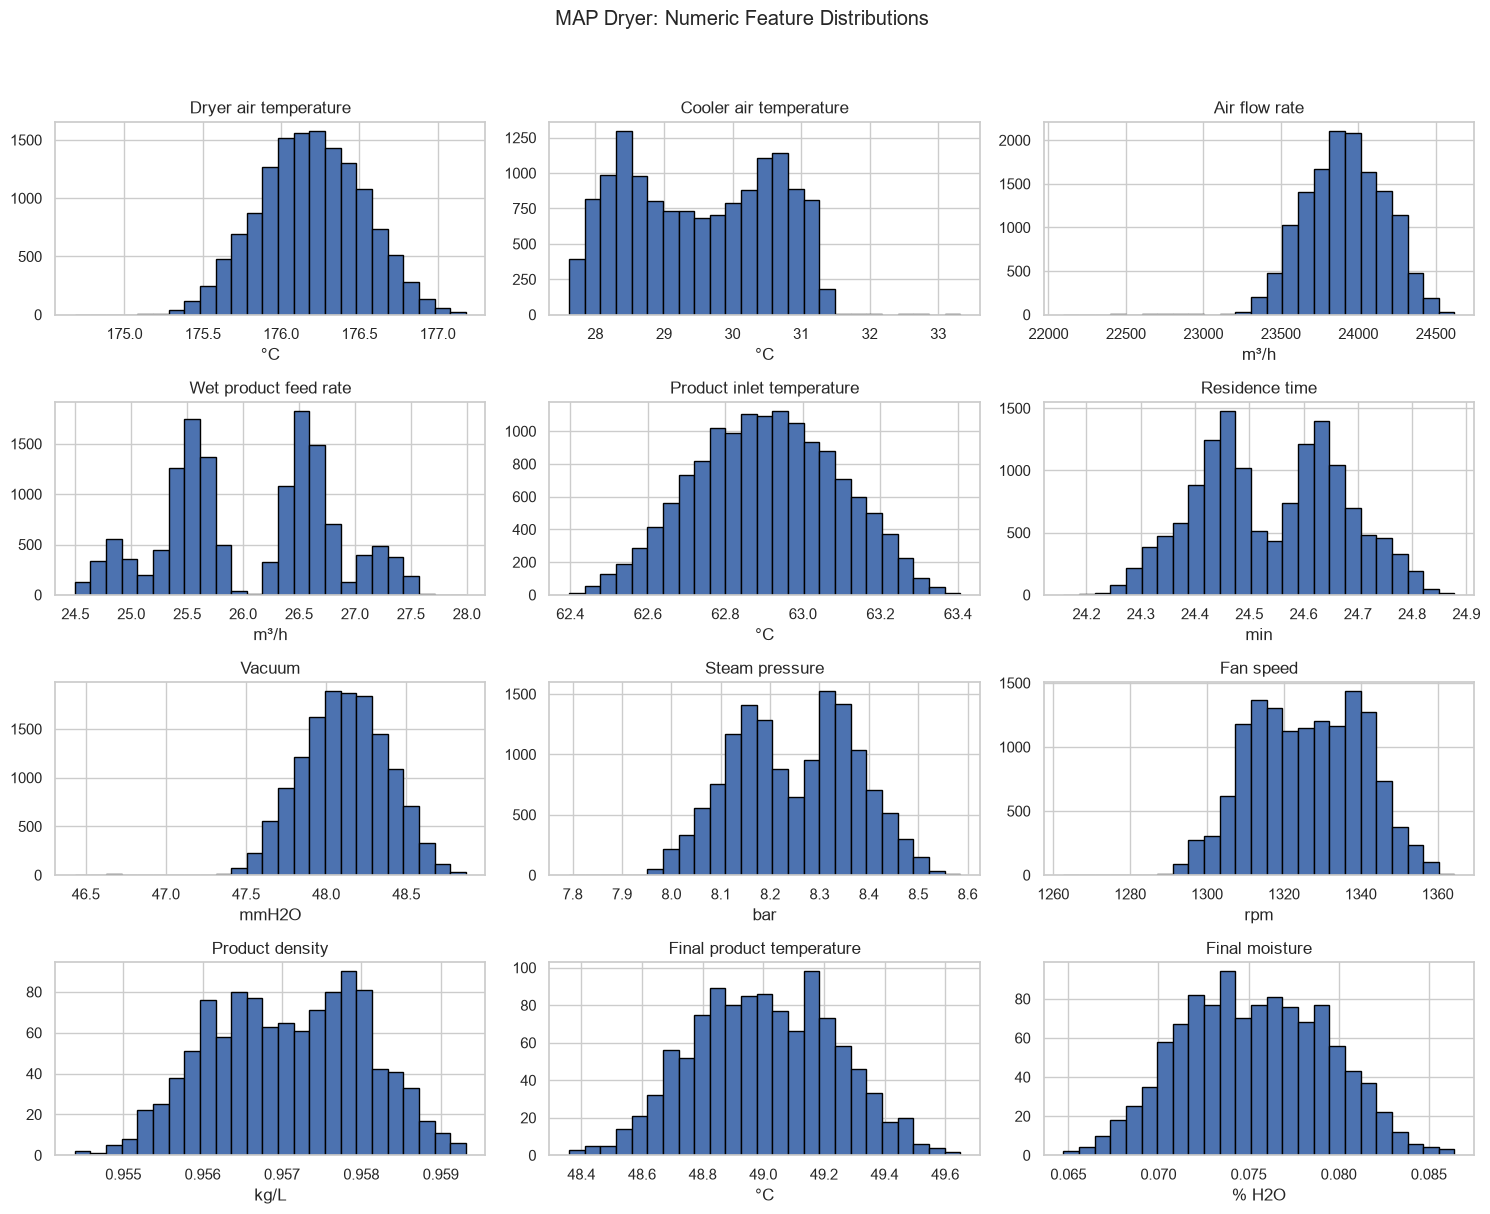

In [7]:
feature_columns = dryerMAP_unique.select_dtypes(include="number").columns

histogram_axes = dryerMAP_unique[feature_columns].hist(
    figsize=(15, 12), bins=25, edgecolor="black"
)
for axis, feature in zip(np.asarray(histogram_axes).reshape(-1), feature_columns):
    axis.set_title(feature_catalog.loc[feature, "display_name"])
    axis.set_xlabel(feature_catalog.loc[feature, "unit"])
for axis in np.asarray(histogram_axes).reshape(-1)[len(feature_columns):]:
    axis.set_visible(False)

plt.suptitle("MAP Dryer: Numeric Feature Distributions", y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(
    FIGURE_OUTPUT_DIR / "01_numeric_feature_distributions.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## Next step

Continue with **Notebook 02: Feature Engineering**, which consumes the same
canonical dataset hash and builds leakage-safe process windows aligned to the
sparse two-hour laboratory observations.
